# 01 · The MVSEC "hexacopter" sequence (`indoor_flying1`)

This repository benchmarks GPS-denied **visual-inertial odometry (VIO)** on the
[MVSEC](https://daniilidis-group.github.io/mvsec/) dataset. MVSEC's
`indoor_flying` sequences were recorded with a **DAVIS346 event-camera rig
(event stream + IMU + grayscale APS frames) flown on a hexacopter**, with a
motion-capture system providing ground-truth poses.

This notebook opens a 15-second slice of `indoor_flying1` (5 s → 20 s) and looks
at each of the four sensor streams the estimators consume:

| Stream | What it is | Used by |
| --- | --- | --- |
| **IMU** | accelerometer + gyro, ~1 kHz | every inertial method |
| **Events** | asynchronous per-pixel brightness changes | `event_vo`, `event_imu`, multimodal |
| **Grayscale frames** | conventional APS images | `rgb_vo`, `image_imu`, multimodal |
| **Ground-truth poses** | motion-capture trajectory | evaluation only |

> The loader, estimators and evaluator are the same code the CLI
> (`python -m nav_benchmark …`) runs — we just call it from Python.

In [1]:
# --- Notebook bootstrap: put the src/ package on the path, pick the dataset ---
import sys, time, warnings
from pathlib import Path

# Find the repo root (the folder that holds pyproject.toml) starting from the
# notebook's working directory, so this runs whether the kernel starts in
# notebooks/ or at the repo root.
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")  # hide benign divide-by-zero notices from the baselines

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.dpi"] = 92

# The "hexacopter" part of MVSEC is the indoor_flying sequences (a DAVIS346
# event camera + IMU + grayscale rig flown on a hexacopter with motion-capture
# ground truth). We use a pre-converted 15 s slice (5 s -> 20 s) of
# indoor_flying1. Prefer the image-inclusive slice; fall back to events+IMU.
DATA = ROOT / "data"
CANDIDATES = ["indoor_flying1_5s20s_img.h5", "indoor_flying1_5s20s.h5"]
SEQ_PATH = next((DATA / c for c in CANDIDATES if (DATA / c).exists()), None)
assert SEQ_PATH is not None, (
    "No hexacopter slice found under data/. Regenerate one (needs the MVSEC bags) with:\n"
    "  uv run python scripts/convert_mvsec_bag_to_h5.py \\\n"
    "    --data-bag data/indoor_flying1_data.bag --gt-bag data/indoor_flying1_gt.bag \\\n"
    "    --output data/indoor_flying1_5s20s_img.h5 --start-sec 5 --duration-sec 15 --include-images"
)
print("Repo root :", ROOT)
print("Sequence  :", SEQ_PATH.name)

Repo root : /home/jovyan/event-based-vio
Sequence  : indoor_flying1_5s20s_img.h5


## Load the sequence

`load_mvsec_sequence` reads the project HDF5 layout into an `MvsecSequence`
(structured NumPy arrays for each stream plus calibration and load
diagnostics).

In [2]:
from nav_benchmark.datasets.mvsec import load_mvsec_sequence

seq = load_mvsec_sequence(SEQ_PATH)

rows = []
for name, count in seq.metadata.sample_counts.items():
    t0, t1 = seq.metadata.time_ranges.get(name, (float("nan"), float("nan")))
    rows.append({"stream": name, "samples": count, "duration_s": round(t1 - t0, 3)})
summary = pd.DataFrame(rows).set_index("stream")
print("Source:", Path(seq.metadata.source_path).name)
print("Calibration intrinsics available:", seq.calibration.intrinsics_available)
if "K" in seq.calibration.data:
    K = np.asarray(seq.calibration.data["K"]).reshape(3, 3)
    print("Camera matrix K:\n", K)
summary

Source: indoor_flying1_5s20s_img.h5
Calibration intrinsics available: True
Camera matrix K:
 [[226.3801852    0.         173.64708079]
 [  0.         226.15002947 133.73271488]
 [  0.           0.           1.        ]]


,samples,duration_s
stream,,
events,3596426,15.000
imu,15010,14.999
gt_poses,1270,14.994
images,470,14.942


## Ground-truth flight path

The motion-capture trajectory is the hexacopter's true path. We show it in 3D,
top-down (x–y), and as height vs. time. Every estimator below is scored against
this reference.

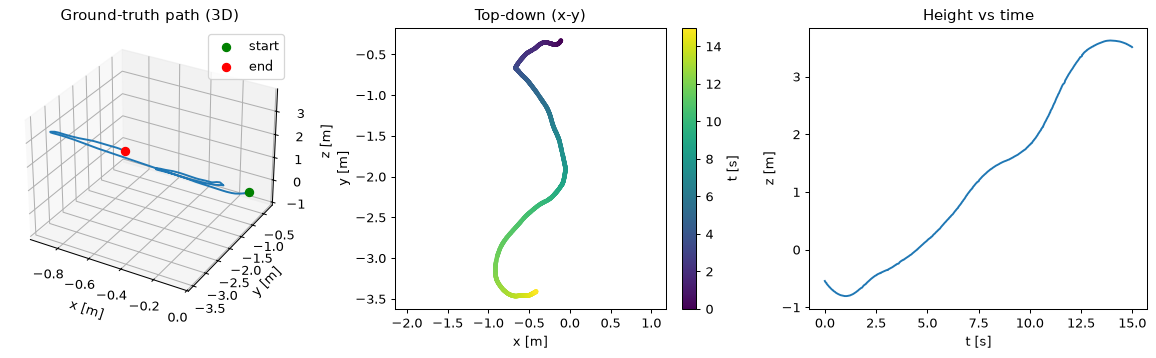

Path length over the slice: 6.66 m


In [3]:
gt = seq.gt_poses
gx, gy, gz, gt_t = gt["x"], gt["y"], gt["z"], gt["t"] - gt["t"][0]

fig = plt.figure(figsize=(13, 4))
ax = fig.add_subplot(1, 3, 1, projection="3d")
ax.plot(gx, gy, gz, lw=1.5)
ax.scatter(gx[0], gy[0], gz[0], c="g", s=40, label="start")
ax.scatter(gx[-1], gy[-1], gz[-1], c="r", s=40, label="end")
ax.set_title("Ground-truth path (3D)"); ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]"); ax.legend()

ax2 = fig.add_subplot(1, 3, 2)
sc = ax2.scatter(gx, gy, c=gt_t, cmap="viridis", s=6)
ax2.set_title("Top-down (x-y)"); ax2.set_xlabel("x [m]"); ax2.set_ylabel("y [m]")
ax2.axis("equal"); fig.colorbar(sc, ax=ax2, label="t [s]")

ax3 = fig.add_subplot(1, 3, 3)
ax3.plot(gt_t, gz)
ax3.set_title("Height vs time"); ax3.set_xlabel("t [s]"); ax3.set_ylabel("z [m]")
plt.tight_layout(); plt.show()

path_len = float(np.sum(np.linalg.norm(np.diff(np.c_[gx, gy, gz], axis=0), axis=1)))
print(f"Path length over the slice: {path_len:.2f} m")

## IMU

Accelerometer (specific force, includes gravity) and gyroscope (angular rate).
IMU-only propagation integrates these — accurate over milliseconds but it drifts
without an absolute reference, which is exactly what the visual/event streams
are there to correct.

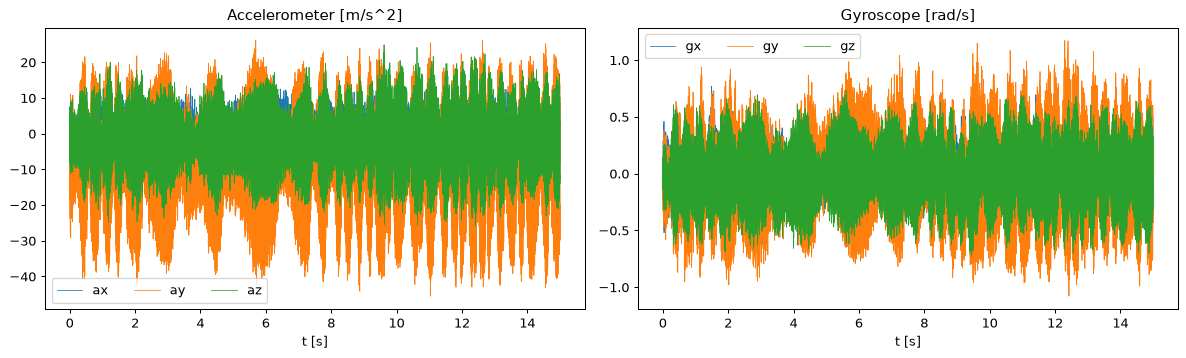

IMU rate ~ 1001 Hz


In [4]:
imu = seq.imu
it = imu["t"] - imu["t"][0]
fig, (a0, a1) = plt.subplots(1, 2, figsize=(13, 4))
for c in ("ax", "ay", "az"):
    a0.plot(it, imu[c], lw=0.6, label=c)
a0.set_title("Accelerometer [m/s^2]"); a0.set_xlabel("t [s]"); a0.legend(ncol=3)
for c in ("gx", "gy", "gz"):
    a1.plot(it, imu[c], lw=0.6, label=c)
a1.set_title("Gyroscope [rad/s]"); a1.set_xlabel("t [s]"); a1.legend(ncol=3)
plt.tight_layout(); plt.show()
print(f"IMU rate ~ {len(imu) / (imu['t'][-1] - imu['t'][0]):.0f} Hz")

## Event camera

Events are asynchronous `(t, x, y, polarity)` tuples. To visualize and to feed
frame-based VO, they are accumulated into fixed-time **event-edge frames**. Below:
the per-window event rate, an accumulated edge image, and an exponential
**time surface** at one instant.

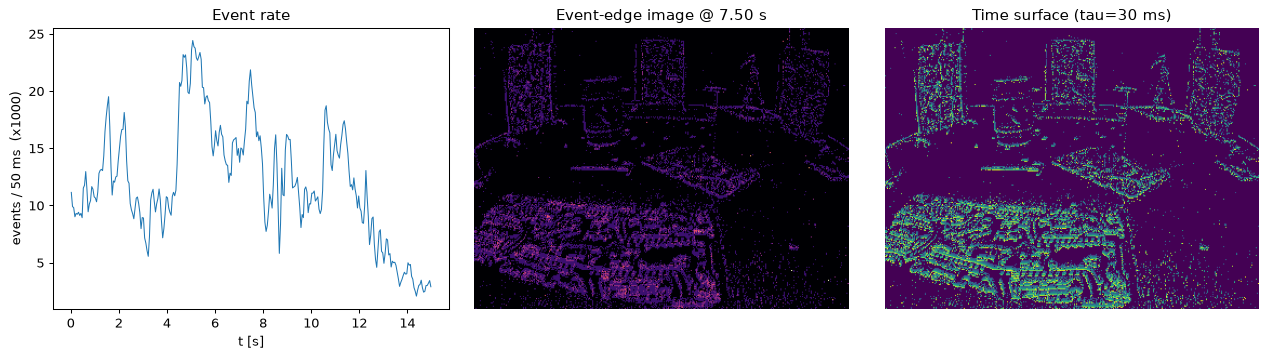

3,596,426 events over 15.0 s  (~0.24 M events/s), sensor 260x346


In [5]:
from nav_benchmark.events.representations import (
    accumulate_event_edges, time_surface, infer_sequence_resolution,
)

H, W = infer_sequence_resolution(seq)
ev = seq.events
ev_t = ev["t"]

# Event rate: counts per 50 ms window across the slice.
win = 0.05
edges = np.arange(ev_t[0], ev_t[-1] + win, win)
rate, _ = np.histogram(ev_t, bins=edges)
rate_t = 0.5 * (edges[:-1] + edges[1:]) - ev_t[0]

# One 50 ms window in the middle for the edge image + time surface.
t_mid = ev_t[0] + 0.5 * (ev_t[-1] - ev_t[0])
mask = (ev_t >= t_mid) & (ev_t < t_mid + win)
window_events = ev[mask]
edge_img = accumulate_event_edges(window_events, H, W)
ts_img = time_surface(window_events, H, W, t_ref=t_mid + win, tau_sec=0.03)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(rate_t, rate / 1000.0, lw=0.8)
axes[0].set_title("Event rate"); axes[0].set_xlabel("t [s]"); axes[0].set_ylabel("events / 50 ms  (x1000)")
axes[1].imshow(edge_img, cmap="magma"); axes[1].set_title(f"Event-edge image @ {t_mid - ev_t[0]:.2f} s"); axes[1].axis("off")
axes[2].imshow(ts_img, cmap="viridis"); axes[2].set_title("Time surface (tau=30 ms)"); axes[2].axis("off")
plt.tight_layout(); plt.show()
print(f"{len(ev):,} events over {ev_t[-1]-ev_t[0]:.1f} s  (~{len(ev)/(ev_t[-1]-ev_t[0])/1e6:.2f} M events/s), sensor {H}x{W}")

## Grayscale (APS) frames

The DAVIS also outputs conventional grayscale frames, which drive the
image-based baselines. (If you loaded the events-only slice, this cell simply
reports that no frames are present.)

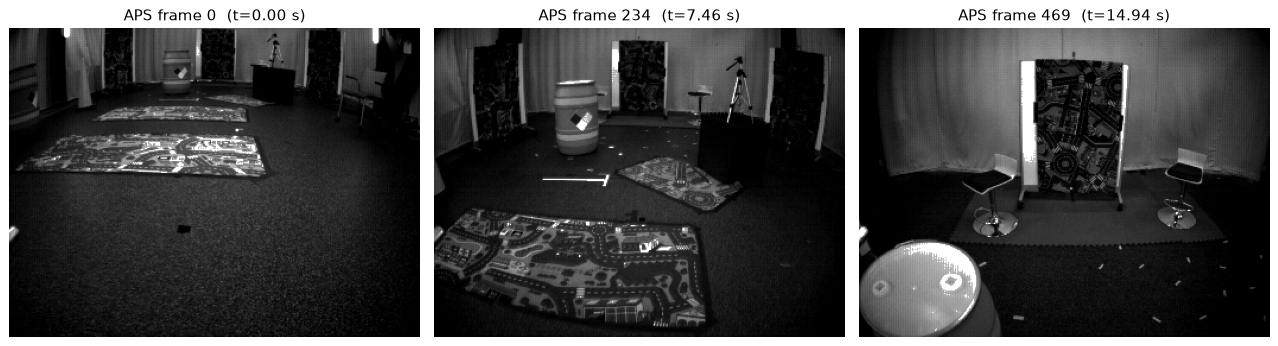

470 grayscale frames (~31 Hz)


In [6]:
if seq.images is not None and len(seq.images) > 0:
    idx = np.linspace(0, len(seq.images) - 1, 3).astype(int)
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, i in zip(axes, idx):
        ax.imshow(seq.images[i], cmap="gray")
        ti = seq.image_timestamps[i] - seq.image_timestamps[0]
        ax.set_title(f"APS frame {i}  (t={ti:.2f} s)"); ax.axis("off")
    plt.tight_layout(); plt.show()
    print(f"{len(seq.images)} grayscale frames "
          f"(~{len(seq.images)/(seq.image_timestamps[-1]-seq.image_timestamps[0]):.0f} Hz)")
else:
    print("This slice carries no grayscale frames (events + IMU only).")

## Takeaways

- The hexacopter slice bundles **four synchronized streams**; the estimators
  differ only in which they trust.
- Events are dense and low-latency but carry no absolute scale; grayscale frames
  are sparse in time; the IMU is fast but drifts.
- **Next:** [`02_odometry_baselines_hexacopter.ipynb`](02_odometry_baselines_hexacopter.ipynb)
  runs each odometry algorithm and scores it against the ground truth above.